In [17]:
from typing import Annotated, List, TypedDict, Union
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from IPython.display import Image, display
import gradio as gr
from langgraph.graph import StateGraph
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
import random
import operator

In [3]:
load_dotenv(override=True)

True

In [6]:
class GraphState(TypedDict):
    #User's original query (e.g., "Why did Spark job X fail?")
    question: str

    #Current generation from the LLM
    generation: str

    #List of retrieved logs, docs or records 
    # Annotated with operator.add so new retrievals append to the list 
    documents: Annotated[List[str], operator.add]   

    #Tracking quality score: 'yes', 'no' or 'maybe'
    is_grounded: str #Hallucination check
    is_relevant: str #Relevance check

    #Counter to prevent infinite loops
    retry_count: int
    
    #Log of steps taken (for debugging and transparency)
    #e.g ['retrieved logs', 'failed hallucination check', 'web search spark docs, 'failed relevance check']
    steps: Annotated[List[str], operator.add]

    #Any misc metadata for Jobs (e.g job_id, env, error_code, etc)
    metadata: dict

In [18]:
# --- 2. DATA MODELS FOR STRUCTURED OUTPUT ---
class GradeDocuments(BaseModel):
    binary_score: str = Field(description="Relevant to question, 'yes' or 'no'")

class GradeHallucinations(BaseModel):
    binary_score: str = Field(description="Grounded in facts, 'yes' or 'no'")

In [19]:
# --- 3. NODES ---
llm = ChatOpenAI(model="gpt-4o", temperature=0)

def retrieve_node(state):
    print("---Retrieving from BFS Vector Store---")
    question = state["question"]

    #Assuming we have a retriever object
    documents = retriever.get_relevant_documents(question)

    #Return documents and update the state
    return {"documents": documents, "steps": ["retrieve_documents"]}

In [20]:
def relevance_grader_node(state):
    """
    Determines whether the retrieved documents are relevant to the question.
    """
    question = state["question"]
    docs = state["documents"]
    
    # We will filter this list
    filtered_docs = []
    # Logic to track if we need to search/improve the KB
    search_required = "no"

    for d in docs:
        # LLM call for each document
        score = llm.invoke({
            "question": question, 
            "context": d.page_content
        })
        
        if score.binary_score == "yes":
            filtered_docs.append(d)
        else:
            search_required = "yes" # At least one doc was bad, or list is empty
            continue

    return {
        "documents": filtered_docs, 
        "is_relevant": "yes" if filtered_docs else "no",
        "steps": ["checked_document_relevance"]
    }

In [22]:
##SYSTEM PROMPT FOR GENERATOR NODE 
SYSTEM_PROMPT = """
You are a Senior Data Engineer specializing in BFS (Banking & Financial Services) 
data pipelines and Apache Spark performance tuning. 

Your task is to provide technical solutions based ONLY on the provided Context 
(logs, documentation, and metadata).

### RULES FOR ACCURACY:
1. GROUNDING: Only use information explicitly stated in the context. 
2. BFS CONTEXT: If the question involves job syncs, OOM errors, or data extraction, 
   be specific about error codes and timestamps found in the logs.
3. INSUFFICIENT DATA: If the provided context does not contain enough information 
   to answer the question definitively, you MUST respond exactly with:
   "I don't know - The current knowledge base is insufficient to answer this."

### FORMATTING:
- Use bullet points for technical steps.
- If referencing a specific log entry, quote the relevant line.
- Do not make up configurations or BFS policies.

If you fulfill these conditions and have enough data, provide a detailed 
troubleshooting guide or root cause analysis.
"""

In [21]:
def generate_node(state):
    print("--- GENERATING FINAL ANSWER ---")
    question = state["question"]
    documents = state["documents"]
    
    # 1. Prepare the Context string from our accumulated documents
    context = "\n\n".join([doc.page_content for doc in documents])
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", SYSTEM_PROMPT),
        ("human", f"Context:\n{context}\n\nQuestion: {question}")
    ])
    
    # 3. Chain execution
    rag_chain = prompt | llm | StrOutputParser()
    response = rag_chain.invoke({"context": context, "question": question})
    
    # 4. Update the state with the generation
    return {"generation": response, "steps": ["generated_answer"]}

In [23]:
def grade_hallucination_node(state):
    print("--- CHECKING FOR HALLUCINATIONS ---")
    
    # Initialize structured LLM grader
    structured_llm_hallucination_grader = llm.with_structured_output(GradeHallucinations)
    
    # Prompt logic
    score = structured_llm_hallucination_grader.invoke({
        "documents": state["documents"],
        "generation": state["generation"]
    })
    
    return {"is_grounded": score.binary_score, "steps": ["grade_hallucination"]}

## At this stage in order to define improve_kb node, it is a good idea to improve the query given by user by feeding it to an LLM 
### Have to do hit and trial to see how the prompts for improving knowledge base are working

In [ ]:
# 1. Define the Rewriter Chain
re_write_prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a technical query optimizer for Spark and BFS data pipelines. "
               "Your goal is to take a failing user query and rewrite it into a specific, "
               "technical search term optimized for logs and documentation."),
    ("human", "Original Query: {question}\n"
              "The current results were insufficient. Formulate an improved, "
              "highly specific technical search query.")
])

# Initialize your LLM (e.g., GPT-4o-mini is great for this)
question_rewriter = re_write_prompt | llm | StrOutputParser()

In [8]:
def improve_kb(state):
    print("--- IMPROVING KNOWLEDGE BASE ---")
    question = state["question"]
    retry_count = state.get("retry_count", 0)

    # 1. Generate a better search query
    better_query = question_rewriter.invoke({"question": question})
    print(f"--- REWRITTEN QUERY: {better_query} ---")

    # 2. Trigger External Search/Scraper
    # This could be your custom BFS scraper or a tool like Tavily
    new_docs = web_search_tool.invoke({"query": better_query})
    
    # 3. Update State
    # Note: Using Annotated[list, operator.add] in your state 
    # ensures these docs are APPENDED, not overwritten.
    return {
        "documents": new_docs, 
        "retry_count": retry_count + 1,
        "steps": ["improved_knowledge_base_with_search"]
    }

In [24]:
# --- 4. ROUTERS (CONDITIONAL EDGES) ---
def decide_to_generate(state):
    # Circuit breaker: Don't loop more than 3 times
    if state["retry_count"] >= 3:
        return "generate"
    
    # Routing based on relevance score
    if state["is_relevant"] == "no":
        return "improve"
    return "generate"

# def decide_to_generate(state):
#     if state["is_relevant"] == "no" and state["retry_count"] < 3:
#         return "improve"
#     return "generate"

In [ ]:
def decide_final_step(state):
    """
    This router sits AFTER the hallucination grader. 
    It makes a three-way choice.
    """
    print("--- FINAL REVIEW ---")
    
    # 1. Check Hallucination first
    if state["is_grounded"] == "no":
        print("--- DECISION: HALLUCINATION DETECTED, RETRYING GENERATION ---")
        return "re-generate"
    
    # 2. Check if the grounded answer actually addresses the question
    # (Optional: You could add another 'grade_answer' node here)
    if "I don't know" in state["generation"]:
        print("--- DECISION: ANSWER INSUFFICIENT, IMPROVING KB ---")
        return "improve_more"
        
    print("--- DECISION: ANSWER IS GROUNDED AND USEFUL ---")
    return "finalize"

In [25]:
# 1. Initialize Graph with your defined State
workflow = StateGraph(GraphState)

# 2. Add Nodes
workflow.add_node("retrieve", retrieve_node)
workflow.add_node("grade_relevance", relevance_grader_node)
workflow.add_node("improve_kb", improve_kb)
workflow.add_node("generate", generate_node)
workflow.add_node("grade_hallucination", grade_hallucination_node)

# 3. Build Edges
workflow.add_edge(START, "retrieve")
workflow.add_edge("retrieve", "grade_relevance")

workflow.add_conditional_edges("grade_relevance",decide_to_generate,
    {
        "improve": "improve_kb",
        "generate": "generate"
    }
)

workflow.add_edge("improve_kb", "retrieve")
workflow.add_edge("generate", "grade_hallucination")

# 4. Add the Conditional Logic


workflow.add_conditional_edges(
    "grade_hallucination",
    decide_final_step,
    {
        "re-generate": "generate",    # Loop back if it hallucinated
        "improve_more": "improve_kb", # Loop back to search if answer is "I don't know"
        "finalize": END               # Success!
    }
)

# 5. Compile
app = workflow.compile()

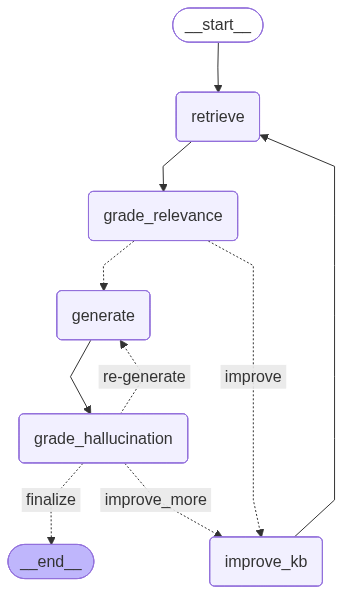

In [27]:
display(Image(app.get_graph().draw_mermaid_png()))